---
## Sorbonne Université
# <center> Mathématiques discrètes </center>
## <center> LU2IN005 </center>
## <div style="text-align:right;"> Année 2024-2025</div>
---

---
# <center> TME programmation d'automates finis </center>
L'objectif de ce TME est de programmer en python quelques uns des
algorithmes pour les automates finis vus en cours et en TD, en
utilisant des structures de données fournies dans le code mis à votre
disposition.
---
# Consignes
Copiez dans votre répertoire de travail les fichiers présents dans le Dossier 
*Fichiers Python fournis* de la page Moodle de l'UE.

Ils contiennent les définitions de structures de données décrites
ci-dessous, ainsi que des aide-mémoire sur l'utilisation de python.

**Le seul fichier que vous êtes autorisés à modifier** est celui-ci, c'est-à-dire
`automate_etudiant.ipynb`, partiellement prérempli. 
Les instructions `return` sont à supprimer lorsque
vous remplirez le contenu des différentes fonctions.  Les autres
fichiers n'ont pas besoin d'être lus (mais ils peuvent l'être).
Si votre programme nécessite de lire des fichiers, **ceux-ci doivent être enregistrés dans le répertoire ExemplesAutomates** que vous avez téléchargé.

Consigne très importante concernant les tests. Vous devez écrire des tests pour vos fonctions. Ces tests doivent être écrits dans les cellules de tests dédiées. Aucun test ne doit être écrit dans une autre cellule, et les cellules de tests ne doivent contenir aucune autre instruction que celles de votre test.
---

Les cellules de tests seront automatiquement effacées lors de l'évaluation de votre programme. 

_Étudiant_

**NOM**: KEDDARA              

**Prénom**: Jalil
                    
**Numéro d'étudiant**: 21312687   


### Table des matières

> [1. Présentation](#sec1)
>> [1.1 La classe `State`](#sec1_1) <br>
>> [1.2 La classe `Transition`](#sec1_2) <br>
>> [1.3 La classe `Automate`](#sec1_3)

> [2. Prise en mains](#sec2)
>> [2.1 Création d'automates](#sec2_1) <br>
>> [2.2 Premières manipulations](#sec2_2) <br>

> [3. Exercices de base : tests et complétion](#sec3)

> [4. Déterminisation](#sec4)

> [5. Constructions sur les automates réalisant des opérations sur les langages acceptés](#sec5)
>> [5.1 Opérations ensemblistes sur les langages](#sec5_1) <br>
>> [5.2 Opérations rationnelles sur les langages](#sec5_2)

In [36]:
## Import des bibliothèques nécessaires au projet.
## Ne pas modifier les fichiers "bibliothèque".

## Interpréter cette cellule avant de continuer.

from transition import *
from state import *
import os
import copy
from automateBase import AutomateBase

class Automate(AutomateBase):
    pass

### 1. Présentation  <a class="anchor" id="sec1"></a>

Le projet utilise le langage python avec une syntaxe légèrement
différente de celle vue en **LU1IN001 / 011**, parce qu'il exploite en particulier
la notion de classes d'objets. Une introduction à cette notion est présentée dans le livre associé
au cours : cf [Chapitre 13](https://www-licence.ufr-info-p6.jussieu.fr/lmd/licence/2021/ue/LU1IN001-2021oct/cours2020.pdf).

De plus, le typage des variables est noté de façon légèrement différente, en commentaires, pour les déclarations
comme pour les arguments des fonctions. Pour ces derniers, les types sont indiqués dans la première ligne de la documentation de la fonction.

Les particularités sont brièvement expliquées en annexe
de ce document. Par ailleurs, vous trouverez dans la section
`projet` de la page Moodle un mémo sur la syntaxe python, ainsi que la carte de
référence du langage utilisée en **LU1IN001 / 011**.  On rappelle qu'une ligne
commençant par `#` est un commentaire, ignoré par
l'interpréteur.

Toutes les structures de données nécessaires à la construction des
automates sont fournies sous la forme de classes python, pour les
transitions d'un automate, ses états, et les automates
eux-mêmes. Cette section indique comment les utiliser.

#### 1.1 La classe `State` <a class="anchor" id="sec1_1"></a>

Un état est représenté par
- un entier `id` (type `int`) qui définit son identifiant,
- un booléen `init` (type `bool`) indiquant si c'est un état initial,
- un booléen `fin` (type `bool`) indiquant si c'est un état final,
- une chaîne de caractères `label` (type `str`) qui définit son étiquette, permettant de le *décorer*. Par défaut, cette variable est la version chaîne de caractères de l'identifiant de l'é
- tat. 

On définit l'alias de type `State` pour représenter les variables de ce type. 

Ainsi, l'instruction ci-dessous crée une variable `s` représentant un état d'identifiant `1`, qui est un état initial mais pas final, dont l'identifiant est aussi l'étiquette  `1` :

In [37]:
#CELLULE DE TEST
# s : State
s = State(1, True, False)

In [38]:
print(s)

1(init)


Si l'on souhaite avoir une étiquette différente de l'identifiant, on
utilise un quatrième argument :

In [39]:
#CELLULE DE TEST
s = State(1, True, False, 'etat 1') 

In [40]:
print(s)

etat 1(init)


On accède ensuite aux différents champs de `s` par la notation pointée : exécutez les cellules suivantes pour observer l'affichage obtenu.

In [41]:
#CELLULE DE TEST
print('La valeur de s.id est : ')
print(s.id)

La valeur de s.id est : 
1


In [42]:
#CELLULE DE TEST
print('La valeur de s.init est : ')
print(s.init)

La valeur de s.init est : 
True


In [43]:
#CELLULE DE TEST
print('La valeur de s.fin est : ')
print(s.fin)

La valeur de s.fin est : 
False


In [44]:
#CELLULE DE TEST
print('La valeur de s.label est : ')
print(s.label)

La valeur de s.label est : 
etat 1


In [45]:
#CELLULE DE TEST
print("L'affichage de s est : ")
print(s)

L'affichage de s est : 
etat 1(init)


Ainsi, une variable de type `State` est affichée par son étiquette et, entre parenthèses, si c'est un état initial et/ou final.

#### 1.2 La classe `Transition` <a class="anchor" id="sec1_2"></a>

Une transition est représentée par 
- un état `stateSrc` (type `State`) correspondant à son état de départ
- un caractère `etiquette` (type `str`) donnant son   étiquette
- un état `stateDest` (type `State`) correspondant à son état de destination

On définit l'alias de type `Transition` pour représenter les variables de ce type.

La séquence d'instructions suivante crée la transition d'étiquette `"a"` de l'état `s` (défini ci-dessus) vers lui-même et affiche les différents champs de la transition :

In [46]:
#CELLULE DE TEST
# t : Transition
t = Transition(s, "a", s)

In [47]:
print(t)

[etat 1(init)-a->etat 1(init)]


In [48]:
#CELLULE DE TEST
print('La valeur de t.etiquette est : ')
print(t.etiquette)

La valeur de t.etiquette est : 
a


In [49]:
#CELLULE DE TEST
print("L'affichage de t.stateSrc est : ")
print(t.stateSrc)

L'affichage de t.stateSrc est : 
etat 1(init)


On remarque que la variable `stateSrc` est de type `State`, on obtient donc un état, et non uniquement un
identifiant d'état. 

In [50]:
#CELLULE DE TEST
print("L'affichage de t.stateDest est : ")
print(t.stateDest)

L'affichage de t.stateDest est : 
etat 1(init)


In [51]:
#CELLULE DE TEST
print("L'affichage de t est : ")
print(t)

L'affichage de t est : 
[etat 1(init)-a->etat 1(init)]


#### 1.3 La classe `Automate` <a class="anchor" id="sec1_3"></a>

Un automate est représenté par
- l'ensemble de ses transitions `allTransitions` (de type `set[Transition]`) 
- l'ensemble de ses états `allStates` (de type `set[State]`)
- une étiquette `label` (de type `str`) qui est éventuellement vide.

On définit l'alias de type `Automate` pour représenter les variables de ce type.

Ainsi, de même que pour les classes précédentes, l'accès aux
différents champs se fait par la notation pointée. Par exemple, on
obtient l'ensemble des états d'un automate `monAutomate` par
l'instruction `monAutomate.allStates`.

Pour créer un automate, il existe trois possibilités.

**Création à partir d'un ensemble de transitions.**<br>
On peut d'abord utiliser le constructeur de signature `Automate : set[Transition] -> Automate`.<br>
Il déduit alors l'ensemble des états à partir de l'ensemble des transitions et définit par défaut l'étiquette
de l'automate comme la chaîne de caractères vide.

Par exemple, en commençant par créer les états et les transitions nécessaires :

In [52]:
#CELLULE DE TEST
## création d'états
# s1 : State
s1 = State(1, True, False)
# s2 : State
s2 = State(2, False, True)

## création de transitions
# t1 : Transition
t1 = Transition(s1,"a",s1)
# t2 : Transition
t2 = Transition(s1,"a",s2)
# t3 : Transition
t3 = Transition(s1,"b",s2)
# t4 : Transition
t4 = Transition(s2,"a",s2)
# t5 : Transition
t5 = Transition(s2,"b",s2)
# set_transitions : set[Transition]
set_transitions = {t1, t2, t3, t4, t5}

## création de l'automate
# aut : Automate
aut = Automate(set_transitions)

L'affichage de cet automate, par la commande `print(aut)` produit alors le résultat suivant : 

In [53]:
#CELLULE DE TEST
print(aut)

Etats :
  1(init)
  2(fin)
Transitions :
  [2(fin)-a->2(fin)]
  [1(init)-b->2(fin)]
  [1(init)-a->1(init)]
  [1(init)-a->2(fin)]
  [2(fin)-b->2(fin)]



Les états de l'automate sont déduits de l'ensemble de transitions.

Optionnellement, on peut donner un nom à l'automate, en utilisant la variable `label`, par exemple :

In [54]:
#CELLULE DE TEST
# aut2 : Automate
aut2 = Automate(set_transitions, label="A") 

print(aut2)

Automate A
Etats :
  1(init)
  2(fin)
Transitions :
  [2(fin)-a->2(fin)]
  [1(init)-b->2(fin)]
  [1(init)-a->1(init)]
  [1(init)-a->2(fin)]
  [2(fin)-b->2(fin)]



**Création à partir d'un ensemble de transitions et d'un ensemble d'états.**<br>
Dans le second cas, on crée un automate à partir d'un ensemble de
transitions mais aussi d'un ensemble d'états, par exemple pour représenter des
automates contenant des états isolés. Pour cela, on utilise le
constructeur `Automate : set[Transition] x set[State] -> Automate`.

On peut également, optionnellement, donner un nom à l'automate :

In [55]:
#CELLULE DE TEST
# set_etats : set[State]
set_etats = {s1, s2}

# aut3 : Automate
aut3 = Automate(set_transitions, set_etats, "B")

print(aut3)

Automate B
Etats :
  1(init)
  2(fin)
Transitions :
  [2(fin)-a->2(fin)]
  [1(init)-b->2(fin)]
  [1(init)-a->1(init)]
  [1(init)-a->2(fin)]
  [2(fin)-b->2(fin)]



L'ordre des paramètres peut ne pas être respecté **à la condition** que l'on donne leur nom explicitement. Ainsi, la ligne suivante est correcte :

In [56]:
#CELLULE DE TEST
aut = Automate(setStates = set_etats, label = "A", setTransitions = set_transitions)

print(aut)

Automate A
Etats :
  1(init)
  2(fin)
Transitions :
  [2(fin)-a->2(fin)]
  [1(init)-b->2(fin)]
  [1(init)-a->1(init)]
  [1(init)-a->2(fin)]
  [2(fin)-b->2(fin)]



**Création à partir d'un fichier contenant sa description.**<br>
La fonction `Automate.creationAutomate : str -> Automate` prend en argument un nom de fichier qui décrit un automate et construit l'automate correspondant (voir exemple ci-dessous).

La description textuelle de l'automate doit suivre le format suivant (voir exemple ci-dessous) :
- #E: suivi de la liste des noms des états, séparés par
  des espaces ou des passages à la ligne. Les noms d'états peuvent
  être n'importe quelle chaîne alphanumérique pouvant également
  contenir le symbole `_`. Par contre, si le nom d'état
  contient des symboles *non numériques* il ne doit pas commencer
  par un chiffre, sous peine de provoquer une erreur à l'affichage.
  Ainsi, `10` et `A1` sont des noms d'états possibles,
  mais `1A` ne l'est pas.
- #I: suivi de la liste des états initiaux
  séparés par des espaces ou des passages à la ligne, 
- #F: suivi de la liste des
  états finaux séparés par des espaces ou des passages à la ligne, 
- #T: suivi de la liste des transitions séparées par des
  espaces ou des passages à la ligne. Chaque transition est donnée
  sous le format `(etat1, lettre, etat2)`.

Par exemple le fichier `exempleAutomate.txt` contenant <br>
`#E: 0 1 2 3`<br>
`#I: 0`<br>
`#F: 3`<br>
`#T: (0 a 0)`<br>
`	(0 b 0)`<br>
`	(0 a 1)`<br>
`	(1 a 2)`<br>
`	(2 a 3)`<br>
`	(3 a 3)`<br>
`	(3 b 3)`<br>
est formaté correctement. L'appel suivant produira l'affichage...

In [57]:
#CELLULE DE TEST
# automate : Automate
automate = Automate.creationAutomate("ExemplesAutomates/exempleAutomate.txt")
print(automate)

Etats :
  0(init)
  1
  2
  3(fin)
Transitions :
  [2-a->3(fin)]
  [1-a->2]
  [0(init)-a->0(init)]
  [0(init)-b->0(init)]
  [3(fin)-a->3(fin)]
  [0(init)-a->1]
  [3(fin)-b->3(fin)]



**Fonctions de manipulation des automates.**<br>
La classe automate contient également de nombreuses fonctions utiles. Elles
s'appliquent à un objet de type `Automate` et s'utilisent donc sous la forme
`aut.<`*fonction*`>(<`*parametres*`>)` où `aut` est une variable de type `Automate`.


- `show : float -> NoneType` <br> 
    prend en argument facultatif un flottant (facteur de grossissement, par défaut il vaut 1.0) et produit une représentation graphique de l'automate.<br> **Attention: nécessite d'avoir installé Graphviz**.
    Ainsi, en utilisant l'automate défini dans le fichier d'exemple précédent, l'instruction `automate.show(1.2)` produit l'image suivante :

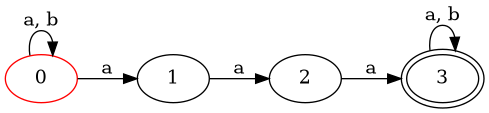

In [58]:
#CELLULE DE TEST
automate.show()

- `addTransition : Transition -> bool`<br>
  prend en argument une transition `t`, fait la mise à jour de
  l'automate en lui ajoutant `t` et ajoute les états impliqués
  dans l'automate s'ils en sont absents. Elle rend `True` si l'ajout a
  eu lieu, `False` sinon (si `t` était déjà présente dans l'automate).
  
- `removeTransition : Transition -> bool`<br>
  prend en argument une transition `t` et fait la mise à jour de
  l'automate en lui enlevant la transition, sans modifier les
  états. Elle rend `True` si la suppression a eu lieu, `False` sinon (si
  `t` était absente de l'automate).

- `addState : State -> bool`<br>
  prend en argument un état `s` et fait la mise à jour de
  l'automate en lui ajoutant `s`.  Elle rend `True` si l'ajout a eu
  lieu, `False` sinon (si `s` était déjà présent dans l'automate).

- `nextId : -> int`<br>
  renvoie un entier id frais, en choisissant l'entier le plus petit,
  strictement supérieur à tous les id des états de l'automate.

- `removeState : State -> bool`<br>
  prend en argument un état `s` et fait la mise à jour de
  l'automate en supprimant `s` ainsi que toutes ses transitions
  entrantes et sortantes.  Elle rend `True` si l'ajout a eu lieu, `False`
  sinon (si `s` était absent de l'automate).
  
- `getSetInitialStates :  -> set[State]`<br> 
  rend l'ensemble des états initiaux.

- `getSetFinalStates :  -> set[State]`<br>
  rend l'ensemble des états finaux.

- `getSetTransitionsFrom : State -> set[Transition]`<br>
  rend l'ensemble des transitions sortant de l'état passé en argument.

- `prefixStates : int -> NoneType`<br>
  modifie les identifiants et les étiquettes de tous les états de
  l'automate en les préfixant par l'entier passé en argument.

- `succElem : State x str -> set[State]`<br>
  étant donné un état `s` et un caractère `a`, elle rend l'ensemble des
  états successeurs de `s` par le caractère `a`.  Formellement,
  
  $$succElem(s, a) = \{s' \in S \mid  s \xrightarrow{a} s'\}.$$
  
  Cet ensemble peut contenir plusieurs états si l'automate n'est pas déterministe.

In [59]:
# Voilà le code de succElem

def succElem(self, state, lettre):
    """ State x str -> set[State]
        rend l'ensemble des états accessibles à partir d'un état state par l'étiquette lettre
    """
    successeurs = set()
    # t: Transitions
    for t in self.getSetTransitionsFrom(state):
        if t.etiquette == lettre:
            successeurs.add(t.stateDest)
    return successeurs

Automate.succElem = succElem

Avec l'exemple précédent, on obtient :

In [60]:
#CELLULE DE TEST
s0 = list(automate.getSetInitialStates())[0] ## on récupère l'état initial de automate
automate.succElem(s0, 'a')

{0(init), 1}

### 2. Prise en mains  <a class="anchor" id="sec2"></a>

#### 2.1 Création d'automates <a class="anchor" id="sec2_1"></a>

Soit l'automate $\mathcal{A}$ défini sur l'alphabet $\{ a,b \}$, d'états $0,1,2$, 
d'état initial 0, d'état final 2 et de transitions : <br>$(0,a,0)$, $(0,b,1)$, 
$(1,a,2)$, $(1,b,2)$, $(2,a,0)$ et $(2,b,1)$.

1. Créer l'automate $\mathcal{A}$ à l'aide de son ensemble de transitions. Pour cela, créer un état `s0`  
d'identifiant $0$
  qui soit initial, un état `s1` d'identifiant $1$ et un état
  `s2` d'identifiant $2$ qui soit final. Puis créer `t1`, `t2`, `t3`, `t4`, `t5` et
  `t6` les 6 transitions de l'automate. Créer enfin l'automate
  `auto` à partir de ses transitions, par exemple avec l'appel<br>
  `auto = Automate({t1,t2,t3,t4,t5,t6})`.<br>
  Vérifier que l'automate correspond bien à $\mathcal{A}$ en l'affichant.

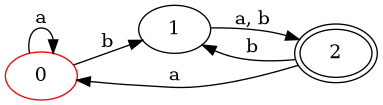

In [61]:
s0 = State(0, True, False)
s1 = State(1, False, False)
s2 = State(2, False, True)


t1 = Transition(s0,"a",s0)
t2 = Transition(s0,"b",s1)
t3 = Transition(s1,"a",s2)
t4 = Transition(s1,"b",s2)
t5 = Transition(s2,"a",s0)
t6 = Transition(s2,"b",s1)


set_transitions = {t1, t2, t3, t4, t5,t6}
auto=Automate(set_transitions)

auto.show()

2. Créer l'automate $\mathcal{A}$ à l'aide de sa liste de
  transitions et d'états, par exemple à l'aide de l'appel<br>
  `auto1 = Automate({t1,t2,t3,t4,t5,t6}, {s0,s1,s2})`<br>
  puis afficher l'automate obtenu à l'aide de `print` puis à l'aide de `show`.
  Vérifier que l'automate `auto1` est bien
  identique à l'automate `auto`.

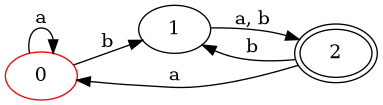

Etats :
  0(init)
  1
  2(fin)
Transitions :
  [0(init)-b->1]
  [1-b->2(fin)]
  [2(fin)-b->1]
  [0(init)-a->0(init)]
  [2(fin)-a->0(init)]
  [1-a->2(fin)]



In [62]:
auto1 = Automate({t1,t2,t3,t4,t5,t6}, {s0,s1,s2})
auto1.show()
print(auto1)

3. Créer l'automate $\mathcal{A}$ à partir d'un fichier. Pour cela,
  créer un fichier `auto2.txt`, dans lequel sont indiqués les
  listes des états et des transitions, ainsi que l'état initial et
  l'état final, en respectant la syntaxe donnée dans la section
  précédente. Par exemple la liste d'états est décrite par la ligne
  `#E: 0 1 2`.  Utiliser ensuite par exemple l'appel
  `auto2 = Automate.creationAutomate("ExemplesAutomates/auto2.txt")`, puis afficher
  l'automate `auto2` à l'aide de `print` ainsi qu'à l'aide de `show`.

Etats :
  0(init)
  1
  2
  3(fin)
Transitions :
  [2-a->3(fin)]
  [1-a->2]
  [0(init)-a->0(init)]
  [0(init)-b->0(init)]
  [3(fin)-a->3(fin)]
  [0(init)-a->1]
  [3(fin)-b->3(fin)]



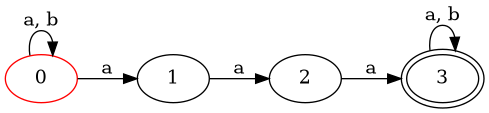

Etats :
  0(init)
  1
  2
  3(fin)
Transitions :
  [2-a->3(fin)]
  [1-a->2]
  [0(init)-a->0(init)]
  [0(init)-b->0(init)]
  [3(fin)-a->3(fin)]
  [0(init)-a->1]
  [3(fin)-b->3(fin)]



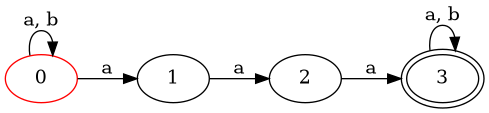

In [63]:
automate = Automate.creationAutomate("ExemplesAutomates/auto2.txt")
print(automate)
automate.show()

auto2 = Automate.creationAutomate("ExemplesAutomates/auto2.txt")
print(automate)
automate.show()


#### 2.2 Premières manipulations <a class="anchor" id="sec2_2"></a>

1. Appeler la fonction `removeTransition` sur l'automate
  `auto` en lui donnant en argument la transition $(0,a,1)$. Il
  s'agit donc de créer une variable `t` de type
  `Transition` représentant $(0,a,1)$ et d'effectuer l'appel
  `auto.removeTransition(t)`. Observer le résultat sur un
  affichage.  Appeler ensuite cette fonction sur `auto` en lui
  donnant en argument la transition `t1`. Observer le résultat
  sur un affichage. Appeler la fonction `addTransition` sur
  l'automate `auto` en lui donnant en argument la transition
  `t1`. Vérifier que l'automate obtenu est bien le même
  qu'initialement.

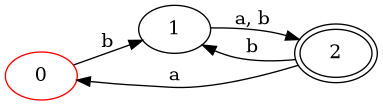

In [64]:
t=Transition(s0,"a",s1)
auto.removeTransition(t1)
auto.show()

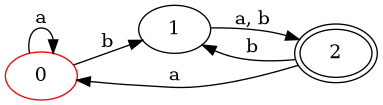

In [65]:
auto.addTransition(t1)
auto.show()

2. Appeler la fonction `removeState` sur l'automate
  `auto` en lui donnant en argument l'état
  `s1`. Observer le résultat. Appeler la fonction
  `addState` sur l'automate `auto` en lui donnant en
  argument l'état `s1`. Créer un état `s0bis` d'identifiant
  $0$ et initial. Appeler la fonction `addState` sur
  `auto` avec `s0bis` comme argument. Observer le résultat.

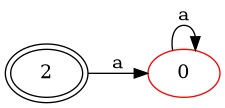

In [66]:
auto.removeState(s1)
s0bis=State(0, True, False)
auto.addState(s0bis)
auto.show()

3. Appeler la fonction `getSetTransitionsFrom` sur
  l'automate `auto1` avec `s1` comme argument. Afficher
  le résultat.

In [67]:
auto1.getSetTransitionsFrom(s1)

{[1-a->2(fin)], [1-b->2(fin)]}

### 3. Exercices de base : tests et complétion  <a class="anchor" id="sec3"></a>

1. Donner une définition de la fonction `succ`
  qui, étant donné un ensemble d'états $S$ et une chaîne de caractères
      $a$ (de longueur 1), renvoie l'ensemble des états successeurs de tous les états de $L$ par le caractère $a$. Cette fonction doit généraliser la fonction `succElem` pour qu'elle prenne en paramètre un ensemble d'états au lieu d'un seul état.  Formellement, si $S$ est un ensemble d'états et $a$ une lettre,
  $$succ(S,a) = \bigcup_{s \in S}succ(s,a) = \{s' \in S \mid \text{il
    existe } s \in L \text{ tel que } s \xrightarrow{a} s'\}.$$

In [68]:
# A faire 

def succ(self, setStates, lettre):
    """ Automate x set[State] x str -> set[State]
        rend l'ensemble des états accessibles à partir de l'ensemble d'états setStates par l'étiquette lettre
    """
    # etatsAccessibles : set[State] — ensemble résultat qui contiendra tous les successeurs trouvés
    etatsAccessibles = set()
    # On parcourt chaque état de l'ensemble fourni en entrée
    for etatCourant in setStates:
        # On récupère les successeurs de cet état via succElem
        # succsElemCourant : set[State]
        succsElemCourant = succElem(self, etatCourant, lettre)
        # On ajoute chaque successeur trouvé dans l'ensemble résultat
        for etatSucc in succsElemCourant:
            etatsAccessibles.add(etatSucc)
    return etatsAccessibles

Automate.succ = succ


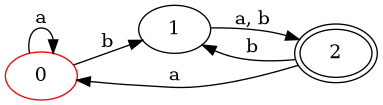

---


In [69]:
#CELLULE DE TEST
# On a défini auparavant un automate auto1, voilà les résultats le concernant, puis un jeu de tests :

auto1.show()
print('---')
assert auto1.succ({s0, s2}, 'b') == {s1}
assert auto1.succ({s0}, 'a') == {s0}
assert auto1.succ({s0, s1}, 'a') == {s0, s2}

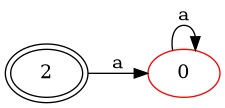

---


In [70]:
assert auto1.succ({s1,s2}, 'b')=={s1,s2}

auto.show()
print('---')
assert auto1.succ({s1, s2}, 'b') == {s1, s2}
assert auto1.succ({s1}, 'a') == {s2}


2. Donner une définition de la fonction `accepte`
  qui, étant donné une chaîne de caractères `mot`,
  renvoie un booléen qui vaut vrai si et seulement si `mot` est accepté par l'automate. Attention, noter que l'automate peut ne pas être déterministe.

In [104]:
def accepte(self, mot):
    """ Automate x str -> bool
        rend True si auto accepte mot, False sinon
    """
    etatsCourants = self.getSetInitialStates()

    for lettre in mot:
        etatsCourants = self.succ(etatsCourants, lettre)

    return len(etatsCourants.intersection(self.getSetFinalStates())) > 0

Automate.accepte = accepte

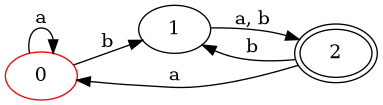

---


In [105]:
#CELLULE DE TEST
# On a défini auparavant un automate auto1, voilà les résultats le concernant, puis un jeu de tests :

auto1.show()
print('---')
assert auto1.accepte('aa') == False
assert auto1.accepte('ab') == False
assert auto1.accepte('aba') == True

In [73]:
auto1.accepte('bbbb')
auto1.allStates


{0(init), 1, 2(fin)}

3. Donner une définition de la fonction `estComplet`
    qui, étant donné un automate `auto` et un ensemble de caractères `Alphabet`
    renvoie un booléen qui vaut vrai si et
    seulement si `auto` est complet par rapport à l'alphabet.
    
    On n'effectuera pas la vérification sur les états non accessibles depuis les états initiaux.

In [106]:
# A faire 

def estVide(ensemble):
    """ set -> bool
        rend True si l'ensemble est vide, False sinon
    """
    # compteur : int — on compte les éléments de l'ensemble
    compteur = 0
    for elem in ensemble:
        compteur = compteur + 1
    # Si aucun élément trouvé, l'ensemble est vide
    if compteur == 0:
        return True
    return False

def etatsAccessibles(self):
    """ Automate -> set[State]
        rend l'ensemble des états accessibles depuis les états initiaux
    """
    accessibles = set(self.getSetInitialStates())
    aTraiter = list(accessibles)

    i = 0
    while i < len(aTraiter):
        etat = aTraiter[i]
        for transition in self.getSetTransitionsFrom(etat):
            if transition.stateDest not in accessibles:
                accessibles.add(transition.stateDest)
                aTraiter.append(transition.stateDest)
        i = i + 1

    return accessibles


def estComplet(self, Alphabet):
    """ Automate x set[str] -> bool
        rend True si auto est complet pour Alphabet
        uniquement sur les états accessibles
    """
    accessibles = self.etatsAccessibles()

    for etat in accessibles:
        for lettre in Alphabet:
            if len(self.succElem(etat, lettre)) == 0:
                return False

    return True

Automate.etatsAccessibles = etatsAccessibles
Automate.estComplet = estComplet


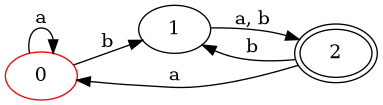

---


In [107]:
#CELLULE DE TEST
# On a défini auparavant un automate auto1, voilà les résultats le concernant, puis un jeu de tests :

auto1.show()
print('---')
assert auto1.estComplet({'a', 'b'}) == True
assert auto1.estComplet({'a', 'c', 'b'}) == False

In [108]:
#CELLULE DE TEST
assert auto1.estComplet({'a', 'b','k'}) == False
assert auto1.estComplet({'a'}) == True
assert auto1.estComplet({'a',' '}) == False

4. Donner une définition de la fonction `estDeterministe`
qui, étant donné un automate `auto`,
 renvoie un booléen qui vaut vrai si et seulement si `auto` est déterministe.

In [109]:
# A faire 

def longueurEnsemble(ensemble):
    """ set -> int
        rend le cardinal de l'ensemble passé en argument
    """
    # compteur : int
    compteur = 0
    for elem in ensemble:
        compteur = compteur + 1
    return compteur

def estDeterministe(self):
    """ Automate -> bool
        rend True si auto est déterministe, False sinon
    """
    if len(self.getSetInitialStates()) != 1:
        return False

    for etat in self.allStates:
        lettresVues = set()

        for transition in self.getSetTransitionsFrom(etat):
            if transition.etiquette in lettresVues:
                return False
            lettresVues.add(transition.etiquette)

    return True

Automate.estDeterministe = estDeterministe

L'appel de fonction `copy.deepcopy(auto)` renvoie un nouvel automate identique à `auto`.

True


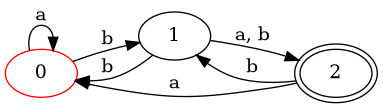

---


In [114]:
auto1bis = copy.deepcopy(auto1)

# On récupère les vrais états de auto1bis
for etat in auto1bis.allStates:
    if etat.label == "0":
        e0 = etat
    if etat.label == "1":
        e1 = etat

# On ajoute une deuxième transition depuis 1 avec la lettre b
t = Transition(e1, "b", e0)

print(auto1bis.addTransition(t))

auto1bis.show()
print("---")

assert auto1bis.estDeterministe() == False

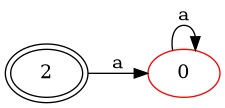

In [115]:
#CELLULE DE TEST
auto.show()
assert auto1.estDeterministe() == True

5. Donner une définition de la fonction `completeAutomate`
qui, étant donné un automate `auto` et l'ensemble alphabet d'entrée `Alphabet`,
renvoie l'automate complété d'`auto`.
  
Attention, il ne faut pas modifier `auto`, mais construire un nouvel automate.
<br>Il pourra être intéressant d'utiliser l'appel de fonction
`copy.deepcopy(auto)` qui renvoie un nouvel automate identique à `auto`.
<br>On pourra faire appel à la fonction `nextId` afin de construire l'état $\bot$.

In [118]:
def completeAutomate(self, Alphabet):
    """ Automate x set[str] -> Automate
        rend l'automate complété de self par rapport à Alphabet
    """
    auto = copy.deepcopy(self)

    if auto.estComplet(Alphabet):
        return auto

    puits = State(auto.nextId(), False, False, "⊥")
    auto.addState(puits)

    for lettre in Alphabet:
        auto.addTransition(Transition(puits, lettre, puits))

    for etat in list(auto.etatsAccessibles()):
        for lettre in Alphabet:
            if len(auto.succElem(etat, lettre)) == 0:
                auto.addTransition(Transition(etat, lettre, puits))

    return auto

Automate.completeAutomate = completeAutomate

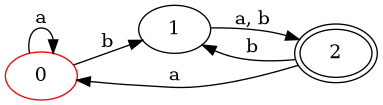

---


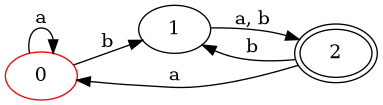

---


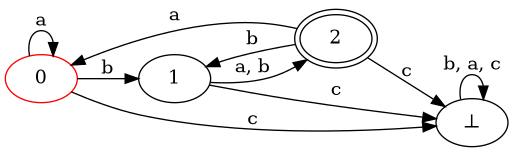

In [119]:
#CELLULE DE TEST
# On a défini auparavant un automate auto1, voilà les résultats le concernant :

auto1.show()
print('---')
assert auto1.estComplet({'a', 'b'}) == True
auto1complet = auto1.completeAutomate({'a', 'b'})
auto1complet.show()
assert auto1complet.estComplet({'a', 'b'}) == True

print('---')
assert auto1.estComplet({'a', 'b', 'c'}) == False
auto1complet = auto1.completeAutomate({'a', 'b', 'c'})
auto1complet.show()
assert auto1complet.estComplet({'a', 'b','c'}) == True

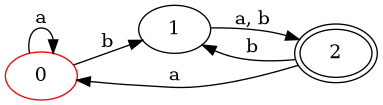

---


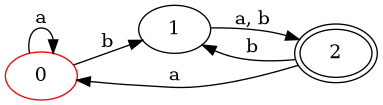

---


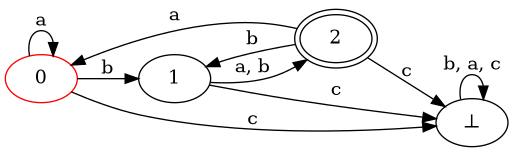

In [120]:
#CELLULE DE TEST
# Fournir un autre jeu de tests
auto1.show()
print('---')
assert auto1.estComplet({'a', 'b'}) == True
auto1complet = auto1.completeAutomate({'a', 'b'})
auto1complet.show()
assert auto1complet.estComplet({'a', 'b'}) == True

print('---')
assert auto1.estComplet({'a', 'b', 'c'}) == False
auto1complet = auto1.completeAutomate({'a', 'b', 'c'})
auto1complet.show()
assert auto1complet.estComplet({'a', 'b','c'}) == True

### 4. Déterminisation  <a class="anchor" id="sec4"></a>

1. Donner une définition de la fonction `newLabel`
qui, étant donné un ensemble d'états renvoie une *chaîne de caractères* représentant l'ensemble de tous les labels des états.
Par exemple, l'appel de `newLabel` sur un ensemble de 3 états dont les labels sont `'1', '2', '3'` renvoie `'{1,2,3}'`

Afin d'être assuré que l'ordre de parcours de l'ensemble des états n'a pas d'importance, il sera nécessaire de trier par ordre alphabétique la liste des `label` des états. On pourra faire appel à `L.sort()` qui étant donné la liste `L` de chaînes de caractères, la trie en ordre alphabétique.

In [111]:
def newLabel(S):
    """ set[State] -> str
        construit un label du type '{0,1,2}'
    """
    labels = []

    for etat in S:
        labels.append(etat.label)

    labels.sort()

    return "{" + ",".join(labels) + "}"

In [112]:
#CELLULE DE TEST
# On a défini auparavant un automate auto1, voilà un test le concernant :

assert newLabel(auto1.allStates) == '{0,1,2}'

In [113]:
#CELLULE DE TEST
assert newLabel(auto.allStates) == '{0,2}'

La fonction suivante permet de déterminiser un automate. On remarque qu'un état peut servir de clé dans un dictionnaire.

In [86]:
def determinisation(self):
    """ Automate -> Automate
        rend l'automate déterminisé de self
    """
    # etatsInitiaux : set[State] — ensemble des états initiaux de l'automate d'origine
    etatsInitiaux = self.getSetInitialStates()
    # estFinal : bool — vrai si l'état initial de l'automate déterminisé est acceptant
    estFinal = False
    for etatInit in etatsInitiaux:
        if etatInit.fin:
            # Au moins un état initial est final : l'état initial déterminisé l'est aussi
            estFinal = True
    # etiquetteInit : str — label de l'état initial de l'automate déterminisé
    etiquetteInit = newLabel(etatsInitiaux)
    # etatInitial : State — premier état de l'automate déterminisé
    etatInitial = State(0, True, estFinal, etiquetteInit)
    # automateDeterm : Automate — automate déterminisé en construction
    automateDeterm = Automate(set())
    automateDeterm.addState(etatInitial)
    # alphabetTrans : set[str] — alphabet déduit des transitions de l'automate d'origine
    alphabetTrans = {transition.etiquette for transition in self.allTransitions}
    # tableEtats : dict[State -> set[State]] — associe chaque état déterminisé à l'ensemble d'états qu'il représente
    tableEtats = dict()
    tableEtats[etatInitial] = etatsInitiaux
    automateDeterm.determinisation_etats(self, alphabetTrans, [etatInitial], 0, tableEtats, {etiquetteInit})
    return automateDeterm


L'automate déterminisé est construit dans `A`. Pour cela la fonction `determinisation_etats` modifie en place l'automate `A`, et prend en outre les paramètres suivants :
- `auto`, qui est l'automate de départ à déterminiser
- `Alphabet` qui contient l'ensemble des lettres étiquetant les transistions de l'automate de départ
- `ListeEtatsATraiter` qui est la liste des états à ajouter et à traiter dans `A` au fur et à mesure que l'on progresse dans `auto`. Initialement cette liste ne contient donc que l'état initial.
- `i` qui est l'indice de l'état en cours de traitement (dans la liste `ListeEtatsATraiter`).
- `Etats` qui est un dictionnaire dont les clés sont les états de `A` et les valeurs associées sont l'ensemble d'états issus de `auto` que cette clé représente.
- `DejaVus` est l'ensemble des labels d'états de `A` déjà vus.

La fonction `determinisation_etats` peut être récursive ou non. Le paramètre `i` n'est utile que si vous programmez une fonction récursive. Dans tous les cas, **ne modifiez pas la signature de la fonction**.

In [87]:
# A faire 

def determinisation_etats(self, auto, Alphabet, ListeEtatsATraiter, i, Etats, DejaVus):
    """ Automate x Automate x set[str] x list[State] x int x dict[State : set[State]], set[str] -> NoneType
        Construit récursivement l'automate déterminisé self à partir de l'automate auto.
        ListeEtatsATraiter grandit au fur et à mesure que de nouveaux états sont découverts.
    """
    # etatEnCours : State — état de l'automate déterminisé que l'on traite à cette étape
    etatEnCours = ListeEtatsATraiter[i]
    # On marque cet état comme déjà visité
    if etatEnCours.label not in DejaVus:
        DejaVus.add(etatEnCours.label)
    for lettre in Alphabet:
        # nouveauxEtats : set[State] — ensemble des états de auto accessibles depuis l'ensemble représenté par etatEnCours
        nouveauxEtats = auto.succ(Etats[etatEnCours], lettre)
        # nouvelleEtiquette : str — label canonique du nouvel ensemble d'états
        nouvelleEtiquette = newLabel(nouveauxEtats)
        if nouvelleEtiquette in DejaVus:
            # L'état correspondant existe déjà : on ajoute juste la transition
            for etatExistant in self.allStates:
                if etatExistant.label == nouvelleEtiquette:
                    self.addTransition(Transition(etatEnCours, lettre, etatExistant))
        else:
            # Nouvel ensemble d'états : on crée un nouvel état dans l'automate déterminisé
            # estFinal : bool — vrai si l'ensemble contient au moins un état final de auto
            estFinal = False
            for etatOrigine in nouveauxEtats:
                if etatOrigine.fin:
                    estFinal = True
            # nouvelEtat : State — représente l'ensemble nouveauxEtats dans l'automate déterminisé
            nouvelEtat = State(self.nextId(), False, estFinal, nouvelleEtiquette)
            self.addState(nouvelEtat)
            self.addTransition(Transition(etatEnCours, lettre, nouvelEtat))
            # On mémorise la correspondance et on ajoute cet état à traiter
            Etats[nouvelEtat] = nouveauxEtats
            ListeEtatsATraiter.append(nouvelEtat)
            DejaVus.add(nouvelleEtiquette)
    # Appel récursif sur l'état suivant dans la liste, si elle n'est pas épuisée
    if (i + 1) < len(ListeEtatsATraiter):
        return determinisation_etats(self, auto, Alphabet, ListeEtatsATraiter, i + 1, Etats, DejaVus)

Automate.determinisation_etats = determinisation_etats
Automate.determinisation = determinisation


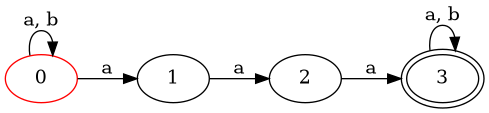

True


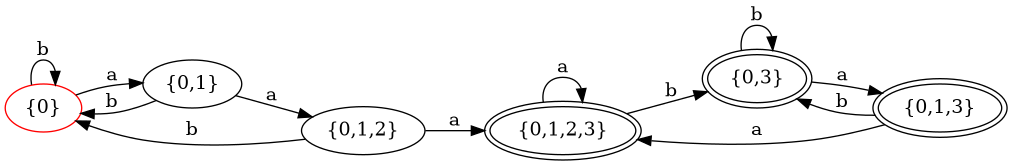

In [88]:
#CELLULE DE TEST
# Voici un test
#automate est l'automate construit plus haut a partir du fichier exempleAutomate.txt
automate = Automate.creationAutomate("ExemplesAutomates/exempleAutomate.txt")
automate.show()
auto_det = automate.determinisation()
print(auto_det.estDeterministe())
auto_det.show(2)

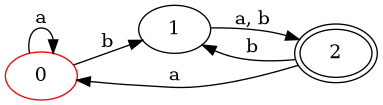

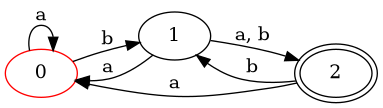

True


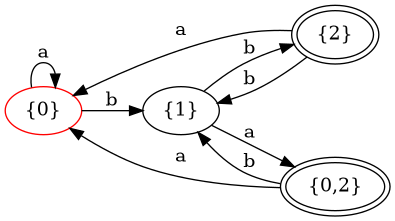

In [89]:
#CELLULE DE TEST
#Fournir d'autres jeux de tests
auto1.show()

assert auto1.estDeterministe() == True

auto1bis = copy.deepcopy(auto1)

t = Transition(s1, 'a', s0)
auto1bis.addTransition(t)
auto1bis.show()


assert auto1bis.estDeterministe() == False

auto1bis_det = auto1bis.determinisation()
print(auto1bis_det.estDeterministe())
auto1bis_det.show()

### 5. Constructions sur les automates réalisant  des opérations sur les langages acceptés <a class="anchor" id="sec5"></a>


#### 5.1 Opérations ensemblistes sur les langages <a class="anchor" id="sec5_1"></a>

1. Donner une définition de la fonction `complementaire` qui, étant donné un automate `auto` et un ensemble de caractères `Alphabet`, renvoie l'automate acceptant la langage complémentaire du langage accepté par `auto`. Ne pas modifier l'automate `auto`, mais construire un nouvel automate.

In [90]:
#A faire

def complementaire(self, Alphabet):
    """ Automate -> Automate
        rend l'automate acceptant pour langage le complémentaire du langage de self.
        Méthode : déterminisation, complétion, puis inversion des états finaux.
    """
    # automateDeterm : Automate — version déterministe de self
    automateDeterm = self.determinisation()
    # automateComplet : Automate — version complète de l'automate déterministe
    automateComplet = automateDeterm.completeAutomate(Alphabet)
    # On inverse le caractère final de chaque état :
    # les états finaux deviennent non finaux et vice-versa
    for etatCourant in automateComplet.allStates:
        if etatCourant.fin:
            etatCourant.fin = False
        else:
            etatCourant.fin = True
    return automateComplet

Automate.complementaire = complementaire


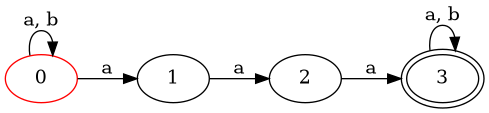

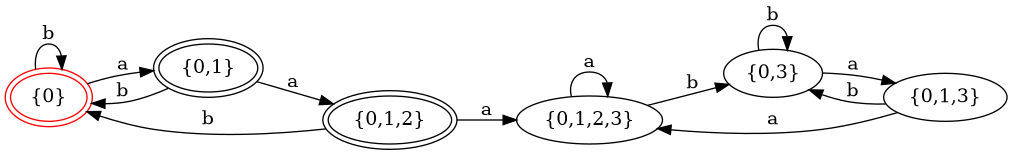

In [91]:
#CELLULE DE TEST
# Voici un test

automate = Automate.creationAutomate("ExemplesAutomates/exempleAutomate.txt")
automate.show()
Alphabet = {t.etiquette for t in auto.allTransitions}
auto_compl = automate.complementaire(Alphabet)
auto_compl.show(2)

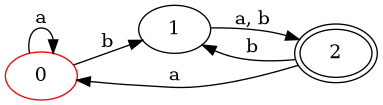

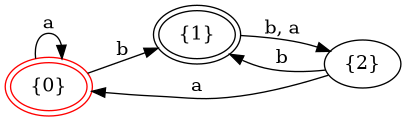

In [92]:
#CELLULE DE TEST
#Fournir d'autres tests
auto1.show()
Alphabet = {t.etiquette for t in auto1.allTransitions}
auto1_compl = auto1.complementaire(Alphabet)
auto1_compl.show()

2. Donner une définition de la fonction `intersection` qui, étant donné deux automates `auto1` et `auto2`, renvoie l'automate acceptant l'intersection des langages acceptés par `auto1` et `auto2`.

L'automate construit ne doit pas avoir d'état non accessible depuis l'état initial.

In [93]:
#A faire par l'étudiant

def intersection(self, auto):
    """ Automate x Automate -> Automate
        rend l'automate acceptant pour langage l'intersection des langages des deux automates.
        Construction par produit synchronisé : les états sont des paires (état de self, état de auto).
    """
    # alphabetCommun : set[str] — alphabet de self (supposé identique à celui de auto)
    alphabetCommun = {transition.etiquette for transition in self.allTransitions}
    # automateInter : Automate — automate intersection en construction
    automateInter = Automate(set())
    # fileTraitement : list[State] — liste des états du produit à traiter
    fileTraitement = []
    indice = 0
    # tableCorrespondance : dict[State -> [State, State]] — associe chaque état produit à ses deux composantes
    tableCorrespondance = dict()
    # etatsDejaVus : set[str] — labels des états produits déjà créés
    etatsDejaVus = set()
    # On initialise avec les paires d'états initiaux
    etatsInitiaux1 = self.getSetInitialStates()
    etatsInitiaux2 = auto.getSetInitialStates()
    for etat1 in etatsInitiaux1:
        for etat2 in etatsInitiaux2:
            # estFinal : bool — vrai si les deux composantes sont finales
            estFinal = False
            if etat1.fin and etat2.fin:
                estFinal = True
            etiquettePaire = "(" + etat1.label + "," + etat2.label + ")"
            etatsDejaVus.add(etiquettePaire)
            nouvelEtat = State(indice, True, estFinal, etiquettePaire)
            automateInter.addState(nouvelEtat)
            fileTraitement.append(nouvelEtat)
            tableCorrespondance[nouvelEtat] = [etat1, etat2]
            indice = indice + 1
    indice = 0
    # Boucle principale : traitement de chaque état produit
    while indice < len(fileTraitement):
        etatEnCours = fileTraitement[indice]
        for lettre in alphabetCommun:
            # successeurs1, successeurs2 : set[State] — successeurs des deux composantes
            successeurs1 = self.succElem(tableCorrespondance[etatEnCours][0], lettre)
            successeurs2 = auto.succElem(tableCorrespondance[etatEnCours][1], lettre)
            for etat1 in successeurs1:
                for etat2 in successeurs2:
                    estFinal = False
                    if etat1.fin and etat2.fin:
                        estFinal = True
                    etiquettePaire = "(" + etat1.label + "," + etat2.label + ")"
                    if etiquettePaire in etatsDejaVus:
                        # L'état produit existe déjà : on ajoute seulement la transition
                        for etatExistant in automateInter.allStates:
                            if etatExistant.label == etiquettePaire:
                                automateInter.addTransition(Transition(etatEnCours, lettre, etatExistant))
                    else:
                        etatsDejaVus.add(etiquettePaire)
                        nouvelEtat = State(automateInter.nextId(), False, estFinal, etiquettePaire)
                        automateInter.addState(nouvelEtat)
                        automateInter.addTransition(Transition(etatEnCours, lettre, nouvelEtat))
                        fileTraitement.append(nouvelEtat)
                        tableCorrespondance[nouvelEtat] = [etat1, etat2]
        indice = indice + 1
    return automateInter

Automate.intersection = intersection


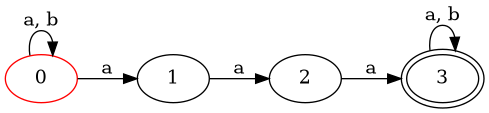

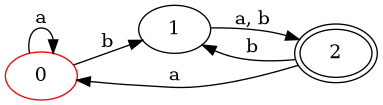

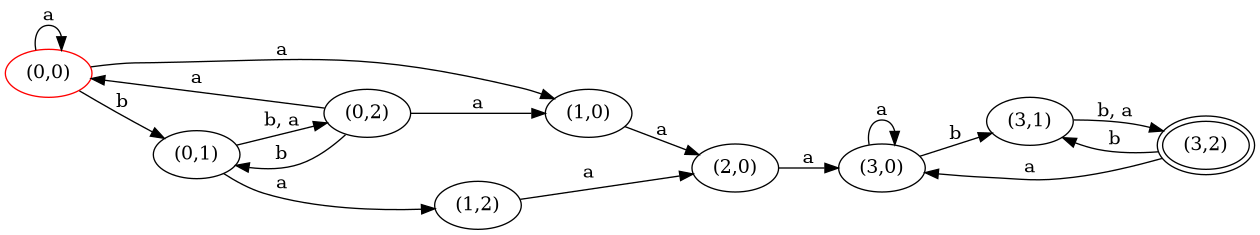

In [94]:
#CELLULE DE TEST
#Un premier test

automate.show()
auto1.show()
inter = automate.intersection(auto1)
inter.show(2)

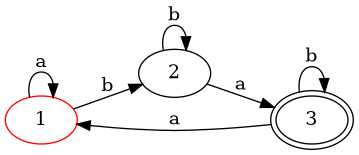

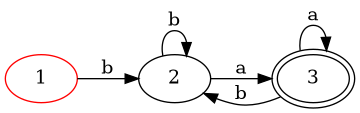

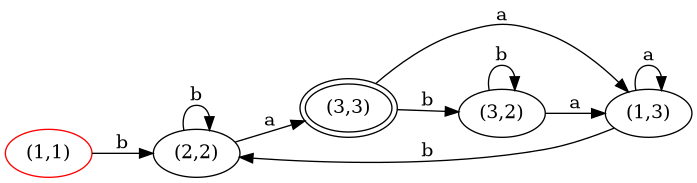

In [95]:
#CELLULE DE TEST
# Fournir d'autres tests

s1 = State(1, True, False, "1")
s2 = State(2, False, False, "2")
s3 = State(3, False, True, "3")
t1 = Transition(s1, "b", s2)
t2 = Transition(s1, "a", s1)
t3 = Transition(s2, "a", s3)
t4 = Transition(s2, "b", s2)
t5 = Transition(s3, "a", s1)
t6 = Transition(s3, "b", s3)
autom1 = Automate({t1, t2, t3, t4 , t5, t6})
autom1.show()

s4 = State(1, True, False, "1")
s5 = State(2, False, False, "2")
s6 = State(3, False, True, "3")
t7 = Transition(s4, "b", s5)
t8 = Transition(s5, "b", s5)
t9 = Transition(s5, "a", s6)
t10 = Transition(s6, "a", s6)
t11 = Transition(s6, "b", s5)
autom2 = Automate({t7, t8, t9, t10, t11})
autom2.show()

inter2 = autom1.intersection(autom2)
inter2.show(2)

3. (Question facultative) Donner une définition de la fonction `union` qui, étant donné deux automates `auto1` `auto2`, renvoie l'automate acceptant comme langage l'union des langages acceptés par `auto1` et `auto2`.

In [96]:
#A faire par l'étudiant

def union(self, auto):
    """ Automate x Automate -> Automate
        rend l'automate acceptant pour langage l'union des langages des deux automates.
        Construction par produit synchronisé sur les automates complétés :
        un état produit est final si au moins l'une de ses composantes est finale.
    """
    # alphabetCommun : set[str]
    alphabetCommun = {transition.etiquette for transition in self.allTransitions}
    # automateUnion : Automate — résultat en construction
    automateUnion = Automate(set())
    fileTraitement = []
    indice = 0
    tableCorrespondance = dict()
    etatsDejaVus = set()
    # On complète les deux automates avant de faire le produit
    auto1Complet = self.completeAutomate(alphabetCommun)
    auto2Complet = auto.completeAutomate(alphabetCommun)
    etatsInitiaux1 = auto1Complet.getSetInitialStates()
    etatsInitiaux2 = auto2Complet.getSetInitialStates()
    # Initialisation avec les paires d'états initiaux
    for etat1 in etatsInitiaux1:
        for etat2 in etatsInitiaux2:
            # estFinal : bool — vrai si au moins une des deux composantes est finale (union)
            estFinal = False
            if etat1.fin or etat2.fin:
                estFinal = True
            etiquettePaire = "(" + etat1.label + "," + etat2.label + ")"
            etatsDejaVus.add(etiquettePaire)
            nouvelEtat = State(indice, True, estFinal, etiquettePaire)
            automateUnion.addState(nouvelEtat)
            fileTraitement.append(nouvelEtat)
            tableCorrespondance[nouvelEtat] = [etat1, etat2]
            indice = indice + 1
    indice = 0
    # Boucle principale identique à l'intersection, mais la condition de finalité est un OU
    while indice < len(fileTraitement):
        etatEnCours = fileTraitement[indice]
        for lettre in alphabetCommun:
            successeurs1 = auto1Complet.succElem(tableCorrespondance[etatEnCours][0], lettre)
            successeurs2 = auto2Complet.succElem(tableCorrespondance[etatEnCours][1], lettre)
            for etat1 in successeurs1:
                for etat2 in successeurs2:
                    estFinal = False
                    if etat1.fin or etat2.fin:
                        estFinal = True
                    etiquettePaire = "(" + etat1.label + "," + etat2.label + ")"
                    if etiquettePaire in etatsDejaVus:
                        for etatExistant in automateUnion.allStates:
                            if etatExistant.label == etiquettePaire:
                                automateUnion.addTransition(Transition(etatEnCours, lettre, etatExistant))
                    else:
                        etatsDejaVus.add(etiquettePaire)
                        nouvelEtat = State(automateUnion.nextId(), False, estFinal, etiquettePaire)
                        automateUnion.addState(nouvelEtat)
                        automateUnion.addTransition(Transition(etatEnCours, lettre, nouvelEtat))
                        fileTraitement.append(nouvelEtat)
                        tableCorrespondance[nouvelEtat] = [etat1, etat2]
        indice = indice + 1
    return automateUnion

Automate.union = union


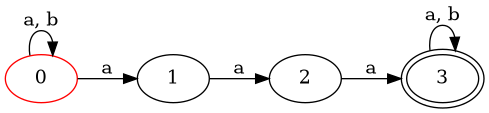

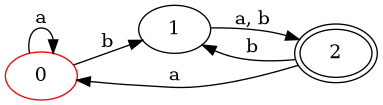

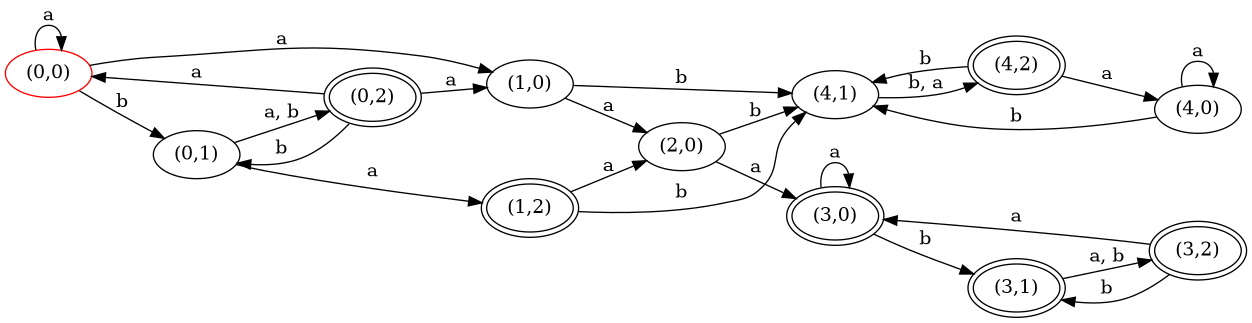

In [97]:
#CELLULE DE TEST
#Un premier test

automate.show()
auto1.show()
uni = automate.union(auto1)
uni.show(2)

#### 5.2 Opérations rationnelles sur les langages <a class="anchor" id="sec5_2"></a>

Programmer *une des deux* méthodes suivantes:

1. Donner une définition de la fonction `concatenation` qui, étant donné deux automates `auto1` et `auto2`, renvoie l'automate acceptant comme langage la concaténation des langages acceptés par `auto1` et `auto2`.

2. Donner une définition de la fonction `etoile` qui, étant donné un automate `auto`, renvoie l'automate acceptant comme langage l'étoile du langages accepté par `auto`.

In [98]:
# A faire

def concatenation(self, auto):
    """ Automate x Automate -> Automate
        rend l'automate acceptant pour langage la concaténation des langages des deux automates.
        Principe : on connecte les états finals du premier automate aux états initiaux du second.
    """
    # auto1Copie, auto2Copie : Automate — copies profondes pour ne pas modifier les originaux
    auto1Copie = copy.deepcopy(self)
    auto2Copie = copy.deepcopy(auto)
    etatsInit1 = auto1Copie.getSetInitialStates()
    etatsFin1 = auto1Copie.getSetFinalStates()
    etats1 = auto1Copie.allStates
    etats2 = auto2Copie.allStates
    trans1 = auto1Copie.allTransitions
    trans2 = auto2Copie.allTransitions
    # initEstFinal : bool — vrai si l'état initial du premier automate est aussi final
    # (dans ce cas les états initiaux du second restent initiaux)
    initEstFinal = True
    if etatsInit1.intersection(etatsFin1) == set():
        initEstFinal = False
    # automateConcat : Automate — automate résultat
    automateConcat = Automate(set())
    # On ajoute tous les états du premier automate
    for etatCourant in etats1:
        automateConcat.addState(etatCourant)
    # nouveauxInits2 : set[State] — anciens états initiaux du second automate (après renommage)
    nouveauxInits2 = set()
    for etatCourant in etats2:
        # On renomme les identifiants du second automate pour éviter les conflits
        etatCourant.id = automateConcat.nextId()
        if etatCourant.init:
            nouveauxInits2.add(etatCourant)
        automateConcat.addState(etatCourant)
    # Ajout des transitions des deux automates
    for transitionCourante in trans1:
        automateConcat.addTransition(transitionCourante)
    for transitionCourante in trans2:
        automateConcat.addTransition(transitionCourante)
    alphabetConcat = {transition.etiquette for transition in self.allTransitions}
    # On relie les états du premier automate aux états initiaux du second
    # chaque fois qu'on peut atteindre un état final du premier
    for etatCourant in automateConcat.allStates:
        if etatCourant in etats1:
            for lettreCourante in alphabetConcat:
                if auto1Copie.succElem(etatCourant, lettreCourante).intersection(etatsFin1) != set():
                    for etatInit2 in nouveauxInits2:
                        automateConcat.addTransition(Transition(etatCourant, lettreCourante, etatInit2))
    # Mise à jour des flags : les états finals du premier et les initiaux du second
    for etatCourant in automateConcat.allStates:
        if etatCourant in etatsFin1:
            etatCourant.fin = False
        if etatCourant in nouveauxInits2 and not initEstFinal:
            etatCourant.init = False
    return automateConcat

Automate.concatenation = concatenation


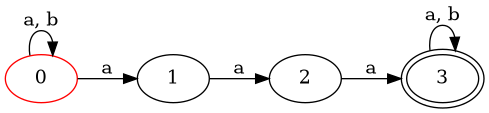

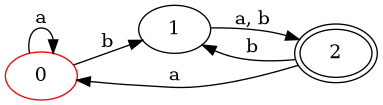

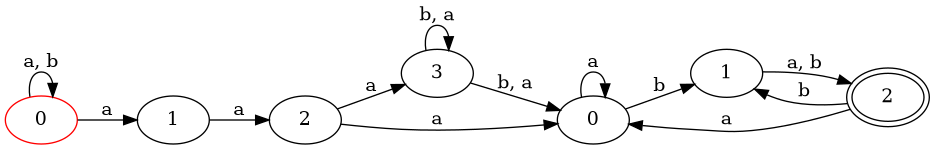

In [99]:
#CELLULE DE TEST
#Un premier test

automate.show()
auto1.show()
concat = automate.concatenation(auto1)
concat.show(2)

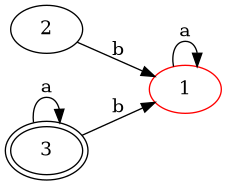

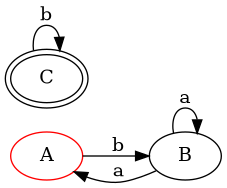

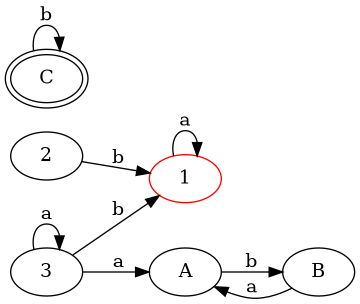

In [100]:
#CELLULE DE TEST
#Fournir un autre jeu de test

s1 = State(0, True, False, "1")
s2 = State(1, False, False, "2")
s3 = State(2, False, True, "3")
t1 = Transition(s1, "a", s0)
t2 = Transition(s2, "b", s1)
t3 = Transition(s3, "a", s3)
t4 = Transition(s3, "b", s1)
automat1 = Automate({t1,t2,t3,t4})
automat1.show()

s5 = State(0, True, False, "A")
s6 = State(1, False, False, "B")
s7 = State(2, False, True, "C")
t5 = Transition(s4, "a", s4)
t6 = Transition(s5, "b", s6)
t7 = Transition(s7, "b", s7)
t8 = Transition(s6, "a", s5)
automat2 = Automate({t5,t6,t7,t8})
automat2.show()

concat2 = automat1.concatenation(automat2)
concat2.show(2)

In [101]:
def etoile(self):
    """ Automate  -> Automate
        rend l'automate acceptant pour langage l'étoile du langage de self.
        Principe : on ajoute des transitions des états qui peuvent atteindre un état final
        vers les états initiaux, puis on ajoute un nouvel état initial et final.
    """
    # autoCopie : Automate — copie profonde de l'automate d'origine
    autoCopie = copy.deepcopy(self)
    tousEtats = autoCopie.allStates
    toutesTransitions = autoCopie.allTransitions
    etatsInitiaux = autoCopie.getSetInitialStates()
    etatsFinals = autoCopie.getSetFinalStates()
    # automateEtoile : Automate — résultat en construction
    automateEtoile = Automate(set())
    for etatCourant in tousEtats:
        automateEtoile.addState(etatCourant)
    for transitionCourante in toutesTransitions:
        automateEtoile.addTransition(transitionCourante)
    alphabetEtoile = {transition.etiquette for transition in self.allTransitions}
    # Pour chaque état, si on peut atteindre un état final par une lettre,
    # on ajoute une transition vers chaque état initial (pour permettre de répéter le langage)
    for etatCourant in automateEtoile.allStates:
        for lettreCourante in alphabetEtoile:
            if autoCopie.succElem(etatCourant, lettreCourante).intersection(etatsFinals) != set():
                for etatInit in etatsInitiaux:
                    automateEtoile.addTransition(Transition(etatCourant, lettreCourante, etatInit))
    # etatInitFinal : State — nouvel état à la fois initial et final (accepte le mot vide)
    etatInitFinal = State(automateEtoile.nextId(), True, True)
    automateEtoile.addState(etatInitFinal)
    return automateEtoile

Automate.etoile = etoile


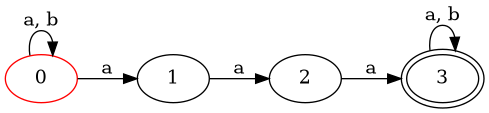

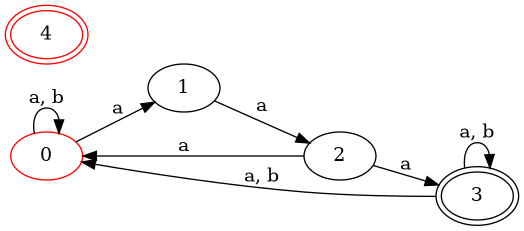

In [102]:
#CELLULE DE TEST
#Un premier test

automate.show()
autoetoile = automate.etoile()
autoetoile.show()

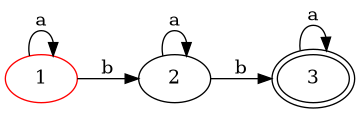

---
---


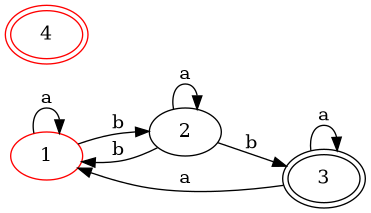

In [103]:
#CELLULE DE TEST
#Fournir un autre jeu de tests

s1 = State(1, True, False, "1")
s2 = State(2, False, False, "2")
s3 = State(3, False, True, "3")
t1 = Transition(s1, "a", s1)
t2 = Transition(s1, "b", s2)
t3 = Transition(s2, "a", s2)
t4 = Transition(s2, "b", s3)
t5 = Transition(s3, "a", s3)
aut = Automate({t1, t2, t3, t4, t5})
aut.show()
print("---")

aut_etoile = aut.etoile()

print("---")

aut_etoile.show()